<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week6_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [11]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset

In [12]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [13]:
#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

Decision Tree Accuracy: 0.951048951048951


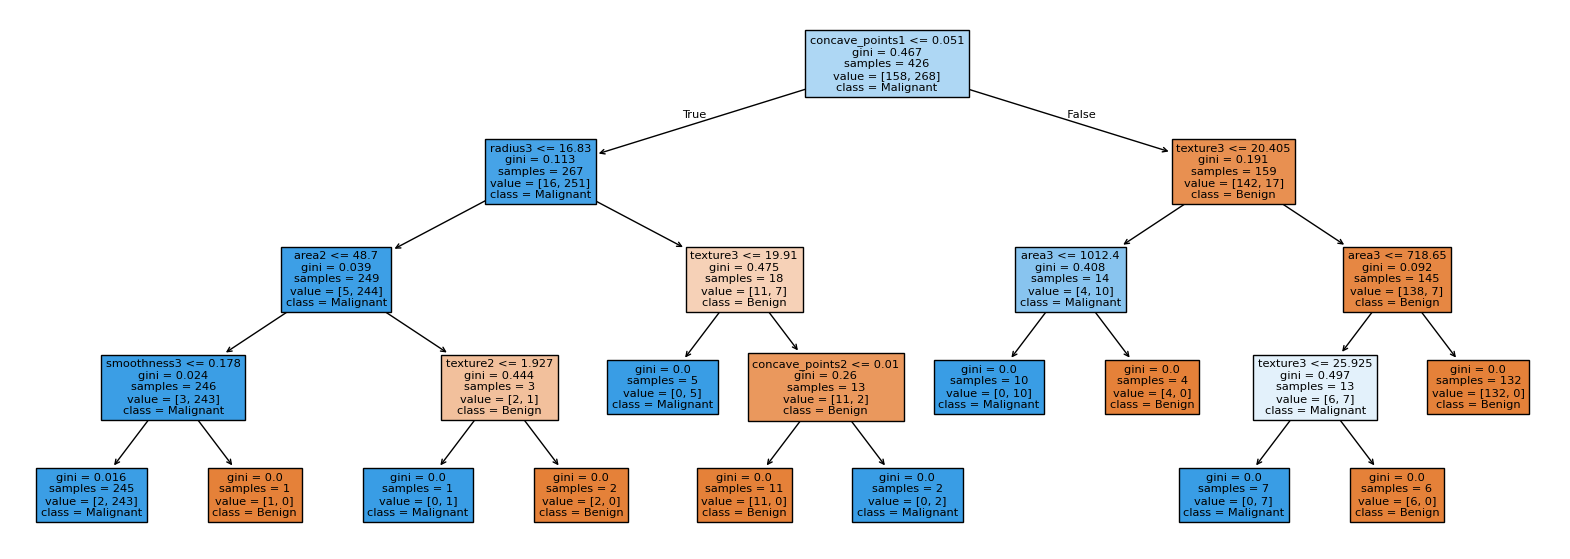

In [17]:
#Training a Decision Tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", tree_accuracy)

#Visualize
plt.figure(figsize=(20,7))
plot_tree(tree, feature_names=X.columns, class_names=["Benign","Malignant"], filled=True)
plt.show()

            Feature  Importance
7   concave_points1    0.710108
21         texture3    0.117840
23            area3    0.064553
20          radius3    0.060194
17  concave_points2    0.017372
13            area2    0.013032
24      smoothness3    0.010057
11         texture2    0.006844
3             area1    0.000000
4       smoothness1    0.000000


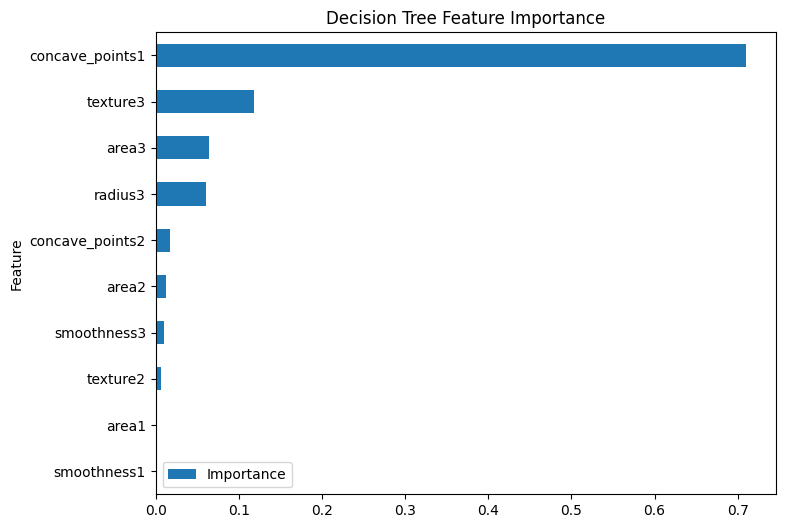

In [20]:
#Feature Importance in Decision Trees
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": tree.feature_importances_})
importance_df = importance_df.sort_values("Importance", ascending=False)
print(importance_df.head(10))
#visualize
importance_df.head(10).sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", figsize=(8,6))
plt.title("Decision Tree Feature Importance")
plt.show()

Accuracy Score:  0.965034965034965

Confusion Matrix: 
 [[51  3]
 [ 2 87]]

Classification Report: 

               precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

------------------------------------------------------------------------------------------


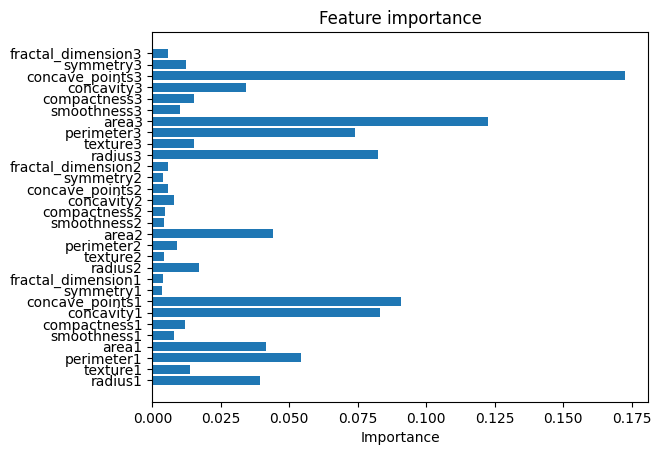

<Figure size 640x480 with 0 Axes>

In [22]:
#Training a Random Forest

rf=RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train,y_train)

#Prediction
y_pred_rf=rf.predict(X_test)

#evaluations
accuracy = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
cr = classification_report(y_test, y_pred_rf)
print("Accuracy Score: ", accuracy)
print("\nConfusion Matrix: \n", cm)
print("\nClassification Report: \n\n", cr)
print("------------------------------------------------------------------------------------------")

#Feature importance
importance_rf = rf.feature_importances_
#plot
plt.barh(X.columns, importance_rf)
plt.xlabel("Importance")
plt.title("Feature importance")
plt.show()
plt.tight_layout()

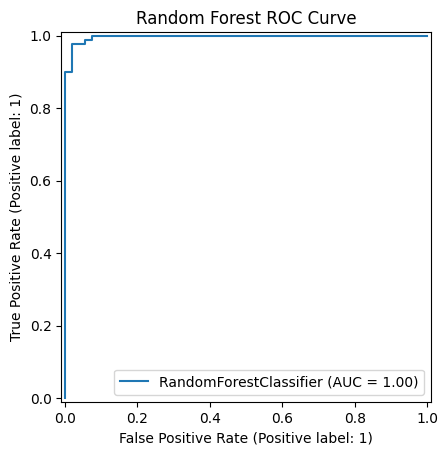

In [32]:
#ROC curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()


In [27]:
#Tune Hyperparameter RandomizedSearchCV
rf=RandomForestClassifier(random_state=42)
param_dist = {"n_estimators": randint(50, 300),
              "max_depth": randint(2,15),
              "min_samples_split": randint(2,10),
              "min_samples_leaf": randint(1,5)}

search = RandomizedSearchCV(
    rf,
    param_distributions = param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_
best_param = search.best_params_
print("Best Model: ", best_model)
print("\nBest Parameters: ", best_param)


Best Model:  RandomForestClassifier(max_depth=10, min_samples_split=4, n_estimators=108,
                       random_state=42)

Best Parameters:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 108}


In [28]:
#Tune Hyperparameter GridSearchCV
param_grid = {'n_estimators': [100,200,500],
              'max_depth': [3,5,10,None],
              'min_samples_split': [2,5,10],
              'min_samples_leaf': [1,2,4]}
grid =  GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_param = grid.best_params_
print("Best Model: ", best_model)
print("\nBest Parameters: ", best_param)


Best Model:  RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

Best Parameters:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


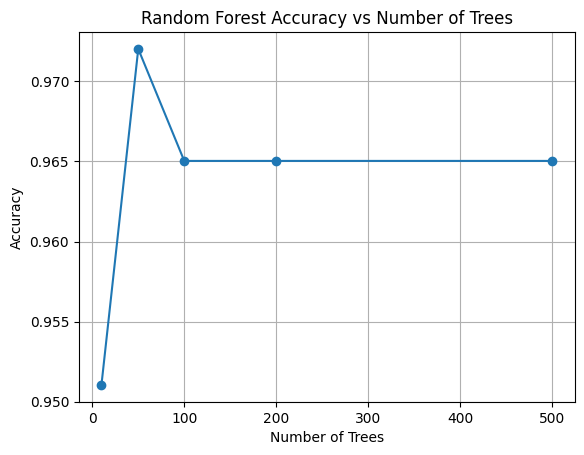

In [29]:
trees = [10, 50, 100, 200, 500]
accuracies = []

for n in trees:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )

plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()